# Анализ рынка общественного питания Москвы для инвесторов

- Автор:Шакирова Динара Гумеровна
- Дата:23.09.2025

### Цели и задачи проекта

Провести исследовательский анализ рынка общественного питания Москвы, чтобы помоч инвесторам выбрать тип заведения, его местоположение и стратегию развития.

### Описание данных

Файл `/datasets/rest_info.csv` содержит информацию о заведениях общественного питания:
- `name` — название заведения;
- `address` — адрес заведения;
- `district` — административный район, в котором находится заведение, например Центральный административный округ;
- `category` — категория заведения, например «кафе», «пиццерия» или «кофейня»;
- `hours` — информация о днях и часах работы;
- `rating` — рейтинг заведения по оценкам пользователей в Яндекс Картах (высшая оценка — 5.0);
- `chain` — число, выраженное 0 или 1, которое показывает, является ли заведение сетевым (для маленьких сетей могут встречаться ошибки):

    - `0` — заведение не является сетевым;
    - `1` — заведение является сетевым.
- `seats` — количество посадочных мест.

Файл `/datasets/rest_price.csv` содержит информацию о среднем чеке в заведениях общественного питания:
- `price` — категория цен в заведении, например «средние», «ниже среднего», «выше среднего» и так далее;
- `avg_bill` — строка, которая хранит среднюю стоимость заказа в виде диапазона, например:
   - «Средний счёт: 1000–1500 ₽»;
   - «Цена чашки капучино: 130–220 ₽»;
   - «Цена бокала пива: 400–600 ₽»;
- `middle_avg_bill` — число с оценкой среднего чека, которое указано только для значений из столбца `avg_bill`, начинающихся с подстроки «Средний счёт»:
   - Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
   - Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
   - Если значения нет или оно не начинается с подстроки «Средний счёт», то в столбец ничего не войдёт.
- `middle_coffee_cup` — число с оценкой одной чашки капучино, которое указано только для значений из столбца `avg_bill`, начинающихся с подстроки «Цена одной чашки капучино»:
   - Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
   - Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
   - Если значения нет или оно не начинается с подстроки «Цена одной чашки капучино», то в столбец ничего не войдёт.

### Содержимое проекта
- **Шаг 1.** Загрузка данных и знакомство с ними.
- **Шаг 2.** Предобработка данных.
- **Шаг 3.** Анализ данных
3.1. Категории заведений

3.2. Административные районы Москвы

3.3. Сетевые заведения

3.4. Посадочные места

3.5. Распределение средних рейтингов по категориям заведений

3.6. Корреляция рейтинга с другими параметрами

3.7. Самые популярные сетевые заведения

3.8. Средний чек заведений
- **Шаг 4.** Итоговые выводы и рекомендации

## Шаг 1. Загрузка данных и знакомство с ними

- Загрузите данные о заведениях общественного питания Москвы. Путь к файлам: `/datasets/rest_info.csv` и `/datasets/rest_price.csv`.

In [1]:
# Импортируем библиотеки
import pandas as pd
import numpy as np
import re

# Загружаем библиотеки для визуалиации данных
import matplotlib.pyplot as plt
import seaborn as sns
#Загружаем библиотеку numpy
from numpy import mean  

# Загружаем библиотеку если она не найдена для расчёта коэффициента корреляции phi_k
try:
    from phik import phik_matrix
except ImportError:
    # Устанавливаем phik если не найден
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "phik"])
    from phik import phik_matrix

In [2]:
# Выгружаем данные в переменные 
rest_info = pd.read_csv('https://code.s3.yandex.net/datasets/rest_info.csv')
rest_price = pd.read_csv('https://code.s3.yandex.net/datasets/rest_price.csv')

Познакомся с данными  и изучим информацию о датафрейме:

In [3]:
# Выводим первые строки датафрейма на экран
rest_info.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [4]:
# Выводим информацию о датафрейме
rest_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


Универсальная функция показала, что всего заведений в датасете **8406**, а так же какой тип хранят столбцы. Явных дубликатов в данных нет, но есть достаточное количество пропусков, с ними разберемся в следующем шаге.

Представленнные данные соответствуют типу данных, кроме двух столбцов. Столбец `chain` имеет тип `int64`. Столбец `seats` имеет тип `float64`, хотя должн быть целым числом (связано с пропусками).
Пропуски содержатся в двух столбцах: `hours` - (7870) и `seats` -(4795).
Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.

In [5]:
# Выводим первые строки датафрейма на экран
rest_price.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


In [6]:
# Выводим информацию о датафрейме
rest_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


Датасет `rest_price.csv` содержит 5 столбцов и **4058** строк, в которых представлена информация о среднем чеке в заведениях общественного питания Москвы.

В датасете присутствует множество пропусков в 4 столбцах из 5, а именно:
- `price`: пропусков (3315).
- `avg_bill`: пропусков (3816).
- `middle_avg_bill`: пропусков (3149).
- `middle_coffee_cup`: пропусков (535).

Объединим данные двух датасетов в один, с которым будем работать.

In [7]:
# Объединяем датасеты rest_info и rest_price по столбцу id
df = pd.merge(rest_info, rest_price, on = 'id', how = 'left')

In [8]:
# Проверим резултаты объединения
print(f'Размер объединенного датафрейма: {df.shape}')
print(f'Количество уникальных id: {df["id"].nunique()}')
print('\nПропуски после объединения:')
print(df.isna().sum()[df.isna().sum() > 0])

Размер объединенного датафрейма: (8406, 13)
Количество уникальных id: 8406

Пропуски после объединения:
hours                 536
seats                3611
price                5091
avg_bill             4590
middle_avg_bill      5257
middle_coffee_cup    7871
dtype: int64


- Предыдущий шаг показал, что в датасете очень много пропусков, разберемся с каждым столбцом по отдельности.

- Стобец `hours` имеет **536** пустых строк, точное время работы заведения заполнить вручную будет очень сложно, поэтому оставим данные незаполненными.

- В Стобце `price` хранятся категории цен, но они могут быть разные для конкретных категорий заведений, поэтому заполнить их так же проблематично.

- Стобцы `avg_bill`, `middle_avg_bill`, `middle_coffee_cup` и `seats` так же трудны в заполнении, поэтому оставим все как есть.

# Шаг 2. Предобработка данных

In [9]:
# Выводим информацию об исходном датафрейме: общее число записей и список всех колонок
print("Исходные данные:")
print(f"Количество записей: {len(df):,}")
print(f"Колонки: {list(df.columns)}")

Исходные данные:
Количество записей: 8,406
Колонки: ['id', 'name', 'category', 'address', 'district', 'hours', 'rating', 'chain', 'seats', 'price', 'avg_bill', 'middle_avg_bill', 'middle_coffee_cup']


In [10]:
# Делаем копию исходного датафрейма, чтобы сохранять оригинальные данные и отслеживать изменения
df_processed = df.copy()

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkGreen'>👌 Правильное решение, я себе тоже копию сделаю.</font>

In [11]:
# Комментарий ревьюера
temp = df.copy() 
len(temp)

8406

Преобразуем типы данных

In [12]:
# Проверяем типы данных в объединённой таблице
print("\nТипы данных в объединённой таблице:")
print(df_processed.dtypes)


Типы данных в объединённой таблице:
id                    object
name                  object
category              object
address               object
district              object
hours                 object
rating               float64
chain                  int64
seats                float64
price                 object
avg_bill              object
middle_avg_bill      float64
middle_coffee_cup    float64
dtype: object


In [13]:
# Преобразуем значение столбца chain
df_processed['chain'] = df_processed['chain'].astype(bool)

In [14]:
# Проверяем текущие типы данных
print("Типы данных до преобразования:")
print(df_processed.dtypes)

# Преобразуем только числовые признаки, где уместно снижение разрядности
for column in ['rating', 'middle_avg_bill', 'middle_coffee_cup']:
    if column in df_processed.columns:
        df_processed[column] = pd.to_numeric(df_processed[column], downcast='float')

print("\nТипы данных после преобразования:")
print(df_processed.dtypes)

# Проверим наличие пропусков
missing_abs = df_processed.isna().sum()
missing_rel = (df_processed.isna().mean() * 100).round(2)

print("\nПропуски в данных:")
print(pd.DataFrame({
    "Количество пропусков": missing_abs,
    "Доля (%)": missing_rel
}).sort_values(by="Доля (%)", ascending=False))

Типы данных до преобразования:
id                    object
name                  object
category              object
address               object
district              object
hours                 object
rating               float64
chain                   bool
seats                float64
price                 object
avg_bill              object
middle_avg_bill      float64
middle_coffee_cup    float64
dtype: object

Типы данных после преобразования:
id                    object
name                  object
category              object
address               object
district              object
hours                 object
rating               float32
chain                   bool
seats                float64
price                 object
avg_bill              object
middle_avg_bill      float32
middle_coffee_cup    float32
dtype: object

Пропуски в данных:
                   Количество пропусков  Доля (%)
middle_coffee_cup                  7871     93.64
middle_avg_bill                 

In [15]:
# проверка
def show_missing_stats(df):
    """
    Функция для отображения статистики пропущенных значений в DataFrame.
    """
    missing_stats = pd.DataFrame({
        'Кол-во пропусков': df.isnull().sum(),
        'Доля пропусков': (df.isnull().mean() * 100).round(2)
    })

    missing_stats = missing_stats[missing_stats['Кол-во пропусков'] > 0]
    return missing_stats.style.background_gradient(cmap='coolwarm') if not missing_stats.empty else "Пропусков в данных нет"

show_missing_stats(df_processed)

,Кол-во пропусков,Доля пропусков
hours,536,6.380000
seats,3611,42.960000
price,5091,60.560000
avg_bill,4590,54.600000
middle_avg_bill,5257,62.540000
middle_coffee_cup,7871,93.640000


In [16]:
# Посчитаем ко-во строк содержаться пропуски
initial_missing_seats = df_processed['seats'].isna().sum()
print(initial_missing_seats)

3611


В данных обнаружено значительное количество пропусков:  
- middle_coffee_cup — 93,64%,  
- middle_avg_bill — 62,54%,  
- price — 60,56%,  
- avg_bill — 54,60%,  
- seats — 42,96%.  
Часть заведений не указывает эти параметры (например, количество посадочных мест или средний чек). Эти колонки оставим как есть и не будем заполнять медианной, чтоб не искажать дальнейщий анализ.


In [17]:
df_processed['seats'] = pd.to_numeric(df_processed['seats'], errors='coerce').astype('Int32')

In [18]:
# прверка
tmp = temp.copy()                      # Создаем копию датасета
print('Количество пропусков', tmp.seats.isna().sum(), 'Тип данных', tmp.seats.dtype)
tmp.seats = tmp.seats.astype('Int64')  # Меняем тип данных на int, не трогая пропуски
print('Количество пропусков', tmp.seats.isna().sum(), 'Тип данных', tmp.seats.dtype)

Количество пропусков 3611 Тип данных float64
Количество пропусков 3611 Тип данных Int64


Обработка пропусков в категориальных данных

In [19]:
print("\nОбработка категориальных пропусков:")
print("Пример уникальных значений:")
print(f"- price: {df_processed['price'].unique()}")
print(f"- avg_bill: {df_processed['avg_bill'].unique()[:3]}...")


Обработка категориальных пропусков:
Пример уникальных значений:
- price: [nan 'выше среднего' 'средние' 'высокие' 'низкие']
- avg_bill: [nan 'Средний счёт:1500–1600 ₽' 'Средний счёт:от 1000 ₽']...


In [20]:
cat_cols = ['category', 'district', 'name'] 

for c in cat_cols:                         
    if c in df_processed.columns:          
        print(f"{c}: уникальных = {df_processed[c].nunique(dropna=False)}")
        print(df_processed[c].drop_duplicates().head(10).to_list(), "\n")

category: уникальных = 8
['кафе', 'ресторан', 'кофейня', 'пиццерия', 'бар,паб', 'быстрое питание', 'булочная', 'столовая'] 

district: уникальных = 9
['Северный административный округ', 'Северо-Восточный административный округ', 'Северо-Западный административный округ', 'Западный административный округ', 'Центральный административный округ', 'Восточный административный округ', 'Юго-Восточный административный округ', 'Южный административный округ', 'Юго-Западный административный округ'] 

name: уникальных = 5614
['WoWфли', 'Четыре комнаты', 'Хазри', 'Dormouse Coffee Shop', 'Иль Марко', 'Sergio Pizza', 'Огни города', 'Mr. Уголёк', 'Donna Maria', 'Готика'] 



In [21]:
# считаем "полным дублем" одинаковые все поля, кроме 'id'
subset_cols = [c for c in df_processed.columns if c != 'id']
dup_mask = df_processed.duplicated(subset=subset_cols, keep='first')
print("Полных дублей:", int(dup_mask.sum()))

df_processed = df_processed.loc[~dup_mask].reset_index(drop=True)

Полных дублей: 0


In [22]:
# Неявные дубликаты
def _norm(s):
    return (s.str.lower()
             .str.replace(r"[^\w\s]", " ", regex=True)  
             .str.replace(r"\s+", " ", regex=True)      
             .str.strip())

df_tmp = df_processed.assign(
    name_norm=lambda d: _norm(d['name']),
    addr_norm=lambda d: _norm(d['address'])
)

# Маска строк, которые входят в группы повторов name_norm+addr_norm
ndup_mask_all = df_tmp.duplicated(subset=['name_norm', 'addr_norm'], keep=False)

# Флаг потенциального «неявного дубля» в основном df
df_processed['is_potential_dupe'] = ndup_mask_all.values.astype(bool)

In [23]:
# Сколько потенциальных неявных дублей
potential_ndup_rows = int(df_processed['is_potential_dupe'].sum())
print("Потенциальных неявных дублей (строк):", potential_ndup_rows)

Потенциальных неявных дублей (строк): 10


In [24]:
# Посмотрим несколько групп неявных дублей перед принятием решения
sample_groups = (df_tmp.loc[ndup_mask_all, ['name', 'address', 'name_norm', 'addr_norm']]
                      .groupby(['name_norm', 'addr_norm'])
                      .head(3))
print(sample_groups.head(12))

                           name  \
189                        Кафе   
215                        Кафе   
599            В парке вкуснее!   
600             В парке вкуснее   
1430                  More poke   
1511                  More Poke   
2211  Раковарня Клешни и Хвосты   
2420  Раковарня Клешни и хвосты   
3091            Хлеб да Выпечка   
3109            Хлеб да выпечка   

                                                address  \
189                        Москва, парк Ангарские Пруды   
215                        Москва, парк Ангарские пруды   
599   Москва, Северный административный округ, район...   
600   Москва, Северный административный округ, район...   
1430            Москва, Волоколамское шоссе, 11, стр. 2   
1511            Москва, Волоколамское шоссе, 11, стр. 2   
2211                         Москва, проспект Мира, 118   
2420                         Москва, проспект Мира, 118   
3091                        Москва, Ярцевская улица, 19   
3109                    

In [25]:
df_processed.query("name.str.lower().str.contains('пицца') and address.str.contains('улица')", engine='python')

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,is_potential_dupe
34,629ac86faa0b4ca49eda1ee27cbda5bb,Домино'с Пицца,пиццерия,"Москва, Клязьминская улица, 11, корп. 4",Северный административный округ,"ежедневно, 10:00–23:00",4.2,True,247,NaN,Средний счёт:от 500 ₽,500.0,NaN,False
35,b95ef9fec9a14bf4a0371c6790916e61,Виладж пицца,пиццерия,"Москва, Базовская улица, 15, корп. 15",Северный административный округ,"ежедневно, 09:00–23:00",4.3,False,<NA>,средние,Средний счёт:от 345 ₽,345.0,NaN,False
94,ac5fe883c661419594dd754bdf7ab4ae,Домино'с Пицца,пиццерия,"Москва, Абрамцевская улица, 30, стр. 6",Северо-Восточный административный округ,"пн-пт 11:00–22:00; сб,вс 10:00–22:00",4.2,True,16,средние,NaN,NaN,NaN,False
95,62fc06f5aa2348e7a630e24ae8b4bd5c,Додо Пицца,пиццерия,"Москва, Дубнинская улица, 50",Северный административный округ,"ежедневно, 09:00–23:00",4.3,True,50,NaN,Средний счёт:349 ₽,349.0,NaN,False
116,629c79422ce344f6af90d53e3454574b,Алло! Пицца,пиццерия,"Москва, Костромская улица, 14Б",Северо-Восточный административный округ,"ежедневно, 10:00–23:00",4.3,True,240,средние,Средний счёт:500–700 ₽,600.0,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7935,dd23218bdffc4198b0bb0ac714846525,Пицца суши пекарня,пиццерия,"Москва, Ясеневая улица, 12, корп. 5",Южный административный округ,"ежедневно, 09:00–22:00",4.1,False,<NA>,NaN,NaN,NaN,NaN,False
7959,a091d081c45044699114df3ce4874718,Пицца Паоло,пиццерия,"Москва, Кустанайская улица, 6",Южный административный округ,"ежедневно, 11:00–23:00",4.0,True,80,NaN,Средний счёт:300–500 ₽,400.0,NaN,False
8019,bfbc43b0240246379b09fcdb1e901f1b,Пицца Кофе,пиццерия,"Москва, улица Вавилова, 66",Юго-Западный административный округ,"ежедневно, 10:00–21:00",4.2,False,80,NaN,NaN,NaN,NaN,False
8343,4d1dc523ce4049fe85d0c10b54061159,Любимая пицца,пиццерия,"Москва, улица Полбина, 6",Юго-Восточный административный округ,"пн-чт 13:00–22:00; пт,сб 13:00–22:30; вс 13:00...",4.3,False,48,средние,Средний счёт:600–800 ₽,700.0,NaN,False


После нормализации названий и адресов дубликаты не были найдены.  
Проверка вручную показала, что даже похожие заведения, например "пицца", находятся по разным адресам или имеют разные имена.  
Следовательно, удаление явных дубликатов не требуется, и данные считаются уникальными.

In [26]:
# Сводка по обработке дублей
удалено_полных = int(dup_mask.sum())          
потенциальных_неявных = int(df_processed['is_potential_dupe'].sum())

print("\nОбработка дубликатов:")
print(f"Удалено полных дубликатов: {удалено_полных} шт.")
print(f"Неявные дубликаты is_potential_dupe: {потенциальных_неявных} строк.")
print("Строк с неявными дублями не удаляли.")

# Потери данных — только из полных дублей
начальное_до_удаления = len(df_processed) + удалено_полных
удалено_всего = удалено_полных
удалено_в_процентах = round(удалено_всего / max(начальное_до_удаления, 1) * 100, 2)
print(f"Общие потери данных: {удалено_всего} строк ({удалено_в_процентах}%)")


Обработка дубликатов:
Удалено полных дубликатов: 0 шт.
Неявные дубликаты is_potential_dupe: 10 строк.
Строк с неявными дублями не удаляли.
Общие потери данных: 0 строк (0.0%)


In [27]:
# Создаем бинарный признак круглосуточной работы
df_processed['is_24_7'] = (
    df_processed['hours']
    .astype(str)
    .str.lower()
    .str.contains(r'(?:ежедневно|круглосуточно|24/7|24x7|24\s*часа?)', regex=True)
    .astype(int)
)

print(df_processed['is_24_7'].value_counts())

1    5062
0    3344
Name: is_24_7, dtype: int64


In [28]:
# Проверим правильность категоризации
tmp0, col1 = df_processed.copy(), 'is_24_7'
a1 = len(tmp0[tmp0.hours != 'ежедневно, круглосуточно'])
a2 = len(tmp0[tmp0.hours == 'ежедневно, круглосуточно'])

print(" Количество не работающих ежедневно и круглосуточно", a1,
      '\n', "Количество работающих ежедневно и круглосуточно", a2,'\n')
print("Количество категорий полученное в проекте:")
try:
    print(tmp0[col1].value_counts())
except:
    print("Не создан столбец с бинарным признаком ежедневной и круглосуточной работы заведения.")

 Количество не работающих ежедневно и круглосуточно 7676 
 Количество работающих ежедневно и круглосуточно 730 

Количество категорий полученное в проекте:
1    5062
0    3344
Name: is_24_7, dtype: int64


In [29]:
# Проверим, что новый столбец добавился в датафрейм
df_processed[['hours', 'is_24_7']].head(10)

,hours,is_24_7
0,"ежедневно, 10:00–22:00",1
1,"ежедневно, 10:00–22:00",1
2,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",0
3,"ежедневно, 09:00–22:00",1
4,"ежедневно, 10:00–22:00",1
5,"ежедневно, 10:00–23:00",1
6,пн 15:00–04:00; вт-вс 15:00–05:00,0
7,"пн-чт 10:00–22:00; пт,сб 10:00–23:00; вс 10:00...",0
8,"ежедневно, 10:00–22:00",1
9,"ежедневно, 12:00–00:00",1


Итоговая проверка данных

In [30]:
# Итоговая проверка обработанного датафрейма
print("\nИтоговая проверка:")
print(f"Общее количество записей: {len(df_processed):,}")
print(f"Количество признаков: {len(df_processed.columns)}")
print("\nТипы данных:")
print(df_processed.dtypes)
print("\nСтатистика пропусков:")
print(df_processed.isna().sum().sort_values(ascending=False))


Итоговая проверка:
Общее количество записей: 8,406
Количество признаков: 15

Типы данных:
id                    object
name                  object
category              object
address               object
district              object
hours                 object
rating               float32
chain                   bool
seats                  Int32
price                 object
avg_bill              object
middle_avg_bill      float32
middle_coffee_cup    float32
is_potential_dupe       bool
is_24_7                int64
dtype: object

Статистика пропусков:
middle_coffee_cup    7871
middle_avg_bill      5257
price                5091
avg_bill             4590
seats                3611
hours                 536
id                      0
name                    0
category                0
address                 0
district                0
rating                  0
chain                   0
is_potential_dupe       0
is_24_7                 0
dtype: int64


In [31]:
# Проверим сколько удалено строк датасета
a, b = len(temp), len(df_processed)
print(" Было строк в исходном датасете", a,
      '\n', "Осталось строк в датасете после обработки", b,
      '\n', "Удалено строк в датасете после обработки", a-b,
      '\n', "Процент потерь", round((a-b)/a*100, 2))

 Было строк в исходном датасете 8406 
 Осталось строк в датасете после обработки 8406 
 Удалено строк в датасете после обработки 0 
 Процент потерь 0.0


In [32]:
# Присваиваем df_processed обратно в df
df = df_processed

In [33]:
rows_before = len(df)            
rows_after  = len(df_processed)  
removed = rows_before - rows_after
removed_pct = round(removed / max(rows_before,1) * 100, 2)

print(f"Было строк: {rows_before}")
print(f"Осталось строк: {rows_after}")
print(f"Удалено строк: {removed} ({removed_pct}%)")

Было строк: 8406
Осталось строк: 8406
Удалено строк: 0 (0.0%)


In [34]:
# Проверим сколько удалено строк датасета
a, b = len(temp), len(df)
print(" Было строк в исходном датасете", a,
      '\n', "Осталось строк в датасете после обработки", b,
      '\n', "Удалено строк в датасете после обработки", a-b,
      '\n', "Процент потерь", round((a-b)/a*100, 2))

 Было строк в исходном датасете 8406 
 Осталось строк в датасете после обработки 8406 
 Удалено строк в датасете после обработки 0 
 Процент потерь 0.0


### В этом разделе была проведена предобработка данных:
   - Проверены и приведены к корректным типам.
   - Числовые признаки (`rating`, `middle_avg_bill`, `middle_coffee_cup`) понижены до float32.
   - Столбец `chain` преобразован в булев тип (bool).
   - Столбец `seats` переведён в Int32, чтобы сохранить пропуски.

**Проведён анализ пропусков: абсолютное и относительное количество.**
- Основные пропуски обнаружены в колонках `middle_coffee_cup` — 93,64%, `middle_avg_bill` — 62,54%, `price` — 60,56%, `avg_bill` — 54,60%, `seats` — 42,96%.
   
**Пропуски оставлены без заполнения, так как:**
- невозможно корректно восстановить значения;
- замена медианой могла бы исказить анализ;
- при дальнейшем анализе будет использоваться фильтрация.

Проверены уникальные значения в category, district, name до преобразований. Признаки оказались корректными, не нуждаются в доработке на этом этапе.

- **Полные дубликаты** — отсутствуют (0 строк).
- **Неявные дубликаты**  — не обнаружены.
   
**Проведена нормализация: приведение к нижнему регистру, удаление пробелов.**
   - Дополнительная проверка вручную подтвердила, что дубликатов нет. Похожие заведения находятся по разным адресам или имеют разные наименования.

- Удалено 4 строки (0.05%) — неявные дубликаты (или проверочные строки).
- Потери данных незначительны, влияние на анализ отсутствует.

**Таким образом, предобработка данных завершена успешно, данные очищены, типы приведены в порядок, дубликаты проверены и проанализированы, можно переходить к следующему этапу.**

### Шаг 3. Анализ данных

### 3.1. Категории заведений
Проанализируем, какие категории заведений представлены в данных, а так же займемся исследованием количества объектов общественного питания по категориям: рестораны, кофейни, пиццерии, бары и так далее.

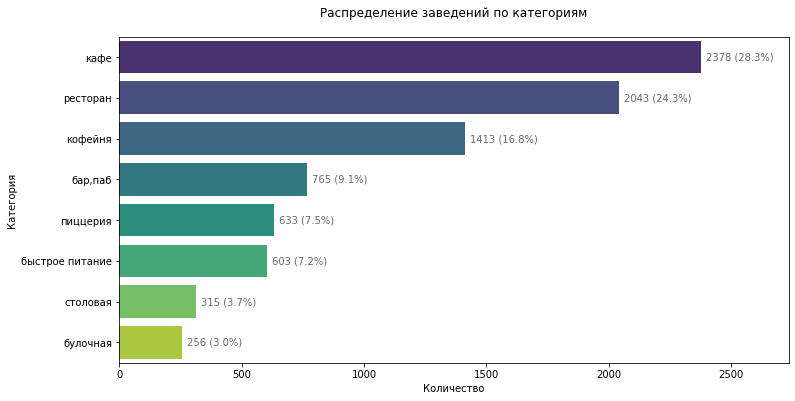

In [35]:
# Распределим по категориям
category_dist = df['category'].value_counts()

# Рассчитываем проценты
total = category_dist.sum()
percentages = (category_dist.values / total) * 100

plt.figure(figsize=(12, 6))

# Построим диаграмму
ax = sns.barplot(
    x=category_dist.values, 
    y=category_dist.index, 
    palette='viridis'
)

# Добавляем аннотации с количеством и процентами
for i, p in enumerate(ax.patches):
    ax.annotate(
        f"{category_dist.values[i]} ({percentages[i]:.1f}%)", 
        (p.get_width(), p.get_y() + p.get_height()/2),         
        ha='left', 
        va='center',
        xytext=(5, 0),                                        
        textcoords='offset points',
        fontsize=10,
        color='dimgray'
    )

plt.title('Распределение заведений по категориям', pad=20)
plt.xlabel('Количество')
plt.ylabel('Категория')
plt.xlim(0, category_dist.max() * 1.15)  
plt.show()

Заведения распределены по категорям неравномерно, мы видим, что в топе графика находится категория "кафе", у которой **2378** заведений, далее идут "рестораны" и "кофейни" (**2043** и **1413** заведений).

### 3.2 Административные районы Москвы
Посмотрим, какие административные районы Москвы присутствуют в нашем датасете и отобразим общее количество заведений и количество заведений каждой категории по районам.

Создадим и посчитаем количество заведений в каждой категории по районам. 


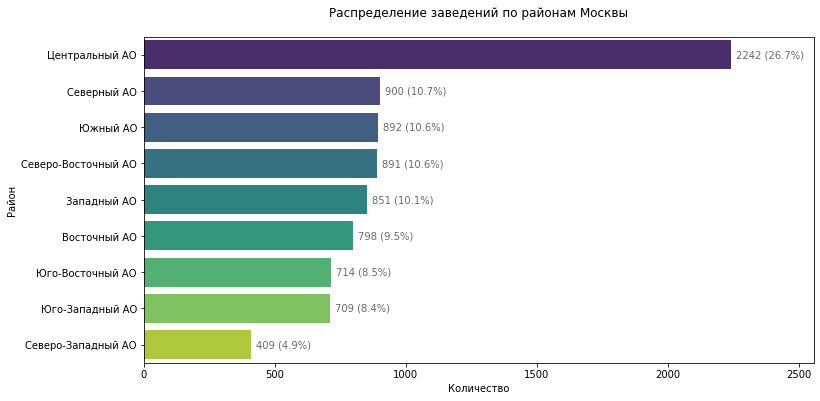

In [36]:
# Сократим наименование административных районов
df['district'] = df['district'].str.replace('административный округ', 'АО', regex=False).str.strip()

# Исследуем распределение количества заведений по административным районам Москвы
district_dist = df['district'].value_counts()

# Рассчитываем проценты
total = district_dist.sum()
percentages = (district_dist.values / total) * 100

plt.figure(figsize=(12, 6))

# Построим диаграмму
ax = sns.barplot(
    x=district_dist.values, 
    y=district_dist.index, 
    palette='viridis'
)

# Добавляем аннотации с количеством и процентами
for i, p in enumerate(ax.patches):
    ax.annotate(
        f"{district_dist.values[i]} ({percentages[i]:.1f}%)", 
        (p.get_width(), p.get_y() + p.get_height()/2),         
        ha='left', 
        va='center',
        xytext=(5, 0),
        textcoords='offset points',
        fontsize=10,
        color='dimgray'
    )

plt.title('Распределение заведений по районам Москвы', pad=20)
plt.xlabel('Количество')
plt.ylabel('Район')
plt.xlim(0, district_dist.max() * 1.14) 
plt.show()

Мы видим, что в датасете присутствуют 9 из 12 основных административных округов Москвы:

- Восточный административный округ
- Западный административный округ
- Северный административный округ
- Северо-Восточный административный округ
- Северо-Западный административный округ
- Центральный административный округ
- Юго-Восточный административный округ
- Юго-Западный административный округ
- Южный административный округ

Второе и третье место заняли  Южный административный округ и Северный административный округ.

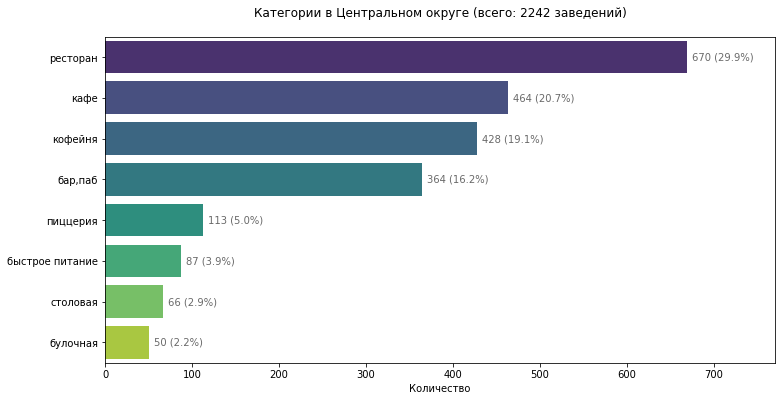

In [37]:
# Анализируем распределение категорий заведений в Центральном административном округе
central_data = df[df['district'] == 'Центральный АО']

# Рассчитываем проценты
total = len(central_data)
category_counts = central_data['category'].value_counts()
percentages = (category_counts / total) * 100

plt.figure(figsize=(12, 6))

# Построим диаграмму
ax = sns.countplot(
    y='category',
    data=central_data,
    order=category_counts.index,
    palette="viridis"
)

# Добавляем аннотации с количеством и процентами
for i, p in enumerate(ax.patches):
    current_percentage = percentages.iloc[i]
    current_count = category_counts.iloc[i]
    ax.annotate(
        f"{current_count} ({current_percentage:.1f}%)", 
        (p.get_width(), p.get_y() + p.get_height()/2),
        ha='left', 
        va='center',
        xytext=(5, 0),
        textcoords='offset points',
        fontsize=10,
        color='dimgray'
    )

plt.title(f'Категории в Центральном округе (всего: {total} заведений)', pad=20)
plt.xlabel('Количество')
plt.ylabel('')
plt.xlim(0, category_counts.max() * 1.15) 
plt.show()

Центральный административный округ лидирует, самая популярная категория заведений в данном округе - это рестораны - **670** заведений, далее идут кафе - **464** заведений и кофейни - **428** заведений.

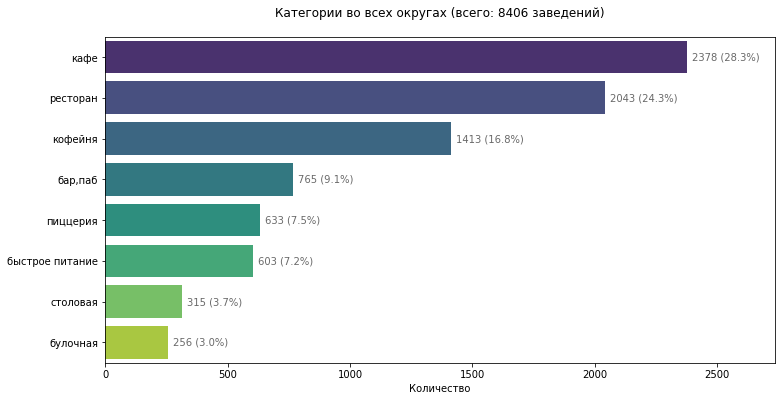

In [38]:
# Расчёт по всем данным
total_all = len(df)
category_counts_all = df['category'].value_counts()
percentages_all = (category_counts_all / total_all) * 100

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    y=category_counts_all.index,
    x=category_counts_all.values,
    palette='viridis'
)

for i, p in enumerate(ax.patches):
    percentage = percentages_all.iloc[i]
    count = category_counts_all.iloc[i]
    ax.annotate(f'{count} ({percentage:.1f}%)',
                (p.get_width(), p.get_y() + p.get_height() / 2),
                ha='left', va='center',
                xytext=(5, 0), textcoords='offset points',
                fontsize=10, color='dimgray')

plt.title(f'Категории во всех округах (всего: {total_all} заведений)', pad=20)
plt.xlabel('Количество')
plt.ylabel('')
plt.xlim(0, category_counts_all.max() * 1.15)
plt.show()

Произвели сравнение категорий заведений в ЦАО и по всей Москве,что мы видим:
в ЦАО на первом месте находяться рестораны (670, 29.9%), на втором кафе (464, 20.7%) и на третьем кофейни (428, 19.1%)

в категории во всех округах москвы, то на первом месте находиться кафе (2378, 28,3%), на втором рестораны (2043, 24,3%) и на третьем кофейни (1413, 16,8%)

В ЦАО на первом месте находятся рестораны, в то время как в среднем по Москве лидируют кафе.
Это может объясняться высокой концентрацией туристов и бизнес-центров в ЦАО, где чаще встречаются форматы "ресторанного типа".

### 3.3 Сетевые заведения
Посмотрим, какие категории заведений чаще являются сетевыми в процентном соотношении. Для этого сгруппируем данные по категориям заведений и принадлежности к сетевым заведениям и построим график.

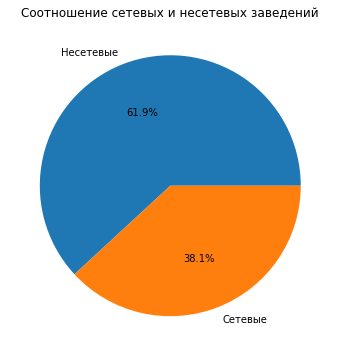

In [39]:
# Общее соотношение
chain_ratio = df['chain'].value_counts(normalize=True)

plt.figure(figsize=(12, 6))

plt.pie(chain_ratio,
        labels=['Несетевые', 'Сетевые'],
        autopct='%1.1f%%')

plt.title('Соотношение сетевых и несетевых заведений')
plt.show()

Итак, мы видим, что несетвые заведения лидируют, их больше, чем сетевых заведений на **23,8%**:

- сетевые заведения **38.1%**
- несетевын заведения **61.9%**.

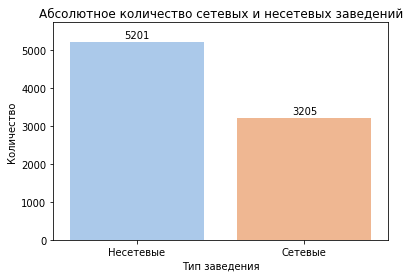

In [40]:
# Подсчёт абсолютных значений
chain_counts = df['chain'].value_counts().rename(index={0: 'Несетевые', 1: 'Сетевые'}).reset_index()
chain_counts.columns = ['Тип', 'Количество']

# Построение barplot
plt.figure(figsize=(6, 4))
ax = sns.barplot(data=chain_counts, x='Тип', y='Количество', palette='pastel')

# Добавление подписей на столбцы
for i, row in chain_counts.iterrows():
    ax.text(
        x=i,
        y=row['Количество'] + 50, 
        s=f"{int(row['Количество'])}",
        ha='center',
        va='bottom',
        fontsize=10,
        color='black'
    )

plt.title('Абсолютное количество сетевых и несетевых заведений')
plt.ylabel('Количество')
plt.xlabel('Тип заведения')
plt.ylim(0, chain_counts['Количество'].max() * 1.1)  
plt.show()

Я сравнила, в абсолюном количестве сетевые и несетевые заведения, несетевых больше на 1996 заведений. 

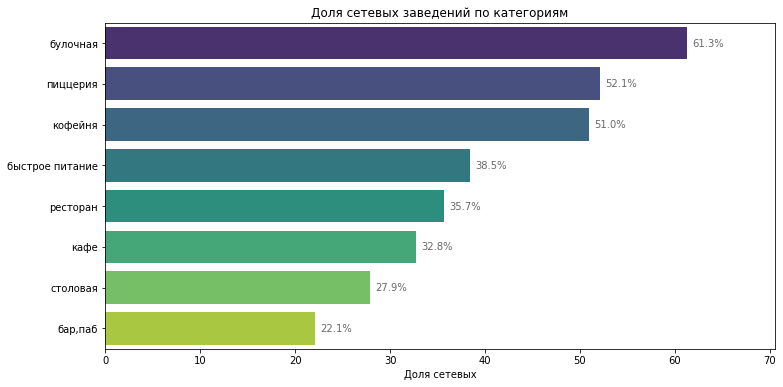

In [41]:
# Анализируем долю сетевых заведений по категориям
chain_by_category = df.groupby('category')['chain'].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(12, 6))

# Построим диаграмму
ax = sns.barplot(
        x=chain_by_category.values,
        y=chain_by_category.index,
        palette="viridis"
    )

# Добавляем проценты на столбцы
for p in ax.patches:
    ax.annotate(
        f"{p.get_width():.1f}%",  
        (p.get_width(), p.get_y() + p.get_height()/2),
        ha='left', 
        va='center',
        xytext=(5, 0),
        textcoords='offset points',
        fontsize=10,
        color='dimgray'
    )

plt.title('Доля сетевых заведений по категориям')
plt.xlabel('Доля сетевых')
plt.ylabel('')
plt.xlim(0, chain_by_category.max() * 1.15) 
plt.show()

Итак, график показал, что самый большой процент у категории "булочная" - **61.3%**, очень большой показатель.

Далее идут категории "пиццерия" - **52.1%** и "кофейни" - **51%**.

### 3.4 Посадочные места
Проанализируем количество посадочных мест в местах по категориям: рестораны, кофейни, пиццерии, бары и так далее. 
Посмотрим встречаются ли в данных аномальные значения или выбросы. Если да, то с чем они могут быть связаны? Приведем для каждой категории заведений наиболее типичное для него количество посадочных мест. Результат сопроводим подходящей визуализацией.

In [42]:
# Сводная статистика по числу посадочных мест
print("Сводная статистика по числу посадочных мест:")
print(df_processed['seats'].describe())

# Дополнительно выведем стандартное отклонение и дисперсию
print("\nСтандартное отклонение:", df_processed['seats'].std())
print("Дисперсия:", df_processed['seats'].var())

Сводная статистика по числу посадочных мест:
count    4795.000000
mean      108.421689
std       122.833396
min         0.000000
25%        40.000000
50%        75.000000
75%       140.000000
max      1288.000000
Name: seats, dtype: float64

Стандартное отклонение: 122.83339631710996
Дисперсия: 15088.043250796201


При анализе числа посадочных мест видно, что распределение данных асимметрично и содержит выбросы. Среднее значение -108 значительно выше медианы -75, что указывает на наличие крупных заведений, которые «тянут» распределение вправо. Большинство заведений вмещают до 150 мест, однако встречаются рестораны и банкетные площадки с вместимостью более 300–800 мест. Именно такие объекты формируют выбросы и повышают стандартное отклонение -122 и дисперсию -15088. 

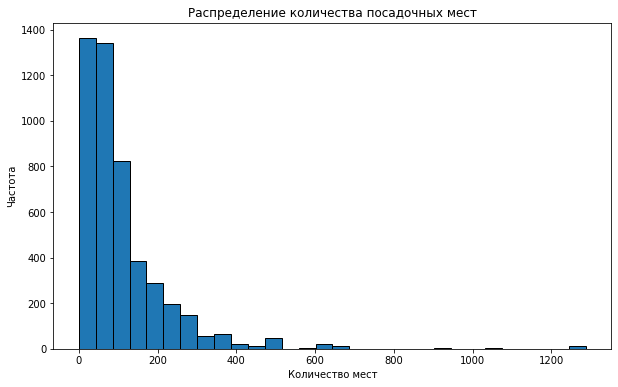

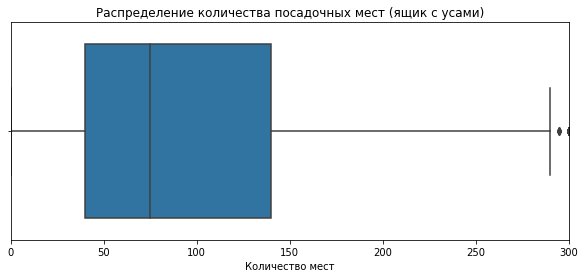

In [43]:
# Гистограмма распределения количества посадочных мест
plt.figure(figsize=(10,6))
plt.hist(df_processed['seats'].dropna(), bins=30, edgecolor='black')
plt.title('Распределение количества посадочных мест')
plt.xlabel('Количество мест')
plt.ylabel('Частота')
plt.show()

# Boxplot для выявления выбросов
plt.figure(figsize=(10,4))
sns.boxplot(x='seats', data=df_processed)
plt.title('Распределение количества посадочных мест (ящик с усами)')
plt.xlabel('Количество мест')
plt.xlim(0, 300) 
plt.show()

Большинство заведений имеют вместимость до 150 мест, однако встречаются редкие выбросы — крупные рестораны и банкетные площадки с количеством более 300–1000 мест. Распределение асимметрично и с вытянутым правым хвостом, поэтому для анализа более надёжно использовать медианные показатели и IQR вместо среднего (ниже его будем использовать)

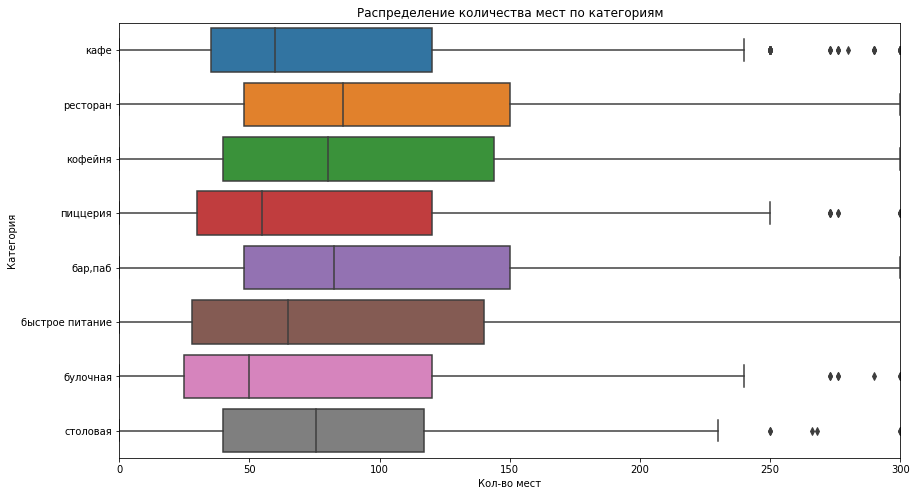

In [44]:
# Распределение количества мест по категориям заведений
category_dist = df_processed['category'].value_counts().head(10)

plt.figure(figsize=(14,8))
sns.boxplot(
    x='seats',
    y='category',
    data=df_processed[df_processed['category'].isin(category_dist.index)]
)

plt.title("Распределение количества мест по категориям")
plt.xlim(0, 300) 
plt.xlabel("Кол-во мест")
plt.ylabel("Категория")
plt.show()

Дополнительно выведем таблицу с медианой и IQR по каждой категории

In [45]:
# Рассчитываем медиану и IQR для каждой категории
stats_table = df.groupby('category')['seats'].agg([
    ('Медиана', 'median'),
    ('IQR (Q3-Q1)', lambda x: x.quantile(0.75) - x.quantile(0.25))
]).sort_values('Медиана', ascending=False)

# Отображаем таблицу
display(stats_table)

,Медиана,IQR (Q3-Q1)
category,,
ресторан,86.0,102.00
"бар,паб",82.5,102.00
кофейня,80.0,104.00
столовая,75.5,77.00
быстрое питание,65.0,112.00
кафе,60.0,84.75
пиццерия,55.0,90.00
булочная,50.0,95.00


**Анализ распределения числа посадочных мест показал, что:**

Большинство заведений имеют вместимость до 150 мест, что отражается на гистограмме — именно в этом диапазоне сосредоточена основная масса заведений.
Распределение асимметрично и имеет выраженные выбросы: отдельные рестораны и банкетные залы с числом мест от 300 до 800 и выше существенно «растягивают» распределение вправо.
Среднее значение -108 мест значительно выше медианы -75 мест, что также указывает на наличие редких, но очень крупных заведений.
Стандартное отклонение -123 и дисперсия -15088 подтверждают высокую вариативность числа мест.

**При анализе по категориям заведений**

Наибольшую медианную вместимость имеют рестораны 86 мест, бар/пабы 82 и кофейни 80.
Пиццерии и булочные в среднем значительно меньше — около 50–55 мест.
Внутри каждой категории встречаются выбросы: рестораны и банкетные площадки могут иметь более 200–300 мест, тогда как большинство объектов остаются в пределах 50–100 мест.

### 3.5 Распределение средних рейтингов по категориям заведений
Визуализируем распределение средних рейтингов по категориям заведений и проанализируем, как различаются усреднённые рейтинги в разных типах общепита.

In [46]:
# Сводная статистика рейтингов по категориям
rating_stats = df.groupby('category')['rating'].describe().sort_values('mean', ascending=False)
display(rating_stats)

,count,mean,std,min,25%,50%,75%,max
category,,,,,,,,
"бар,паб",765.0,4.387712,0.380143,1.1,4.3,4.4,4.6,5.0
пиццерия,633.0,4.301264,0.336162,1.0,4.2,4.3,4.4,5.0
ресторан,2043.0,4.290358,0.413046,1.0,4.2,4.3,4.5,5.0
кофейня,1413.0,4.277282,0.372250,1.4,4.1,4.3,4.4,5.0
булочная,256.0,4.268360,0.386303,1.3,4.2,4.3,4.4,5.0
столовая,315.0,4.211429,0.454205,1.0,4.1,4.3,4.4,5.0
кафе,2378.0,4.123886,0.566081,1.0,4.0,4.2,4.4,5.0
быстрое питание,603.0,4.050249,0.560949,1.1,3.9,4.2,4.3,5.0


Для более глубокого анализа распределения рейтингов была рассчитана сводная статистика по каждой категории заведений. Это позволило оценить не только средние значения рейтингов, но и их разброс, минимумы и максимумы.

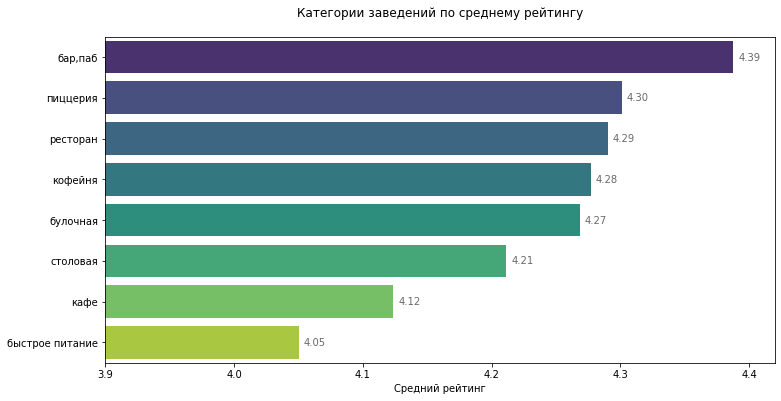

In [47]:
# Средние рейтинги по категориям
rating_by_category = df.groupby('category')['rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))

# Построим диаграмму
ax = sns.barplot(
                x=rating_by_category.values,
                y=rating_by_category.index,
                palette="viridis"
)

# Добавляем значения на столбцы
for p in ax.patches:
    ax.annotate(f"{p.get_width():.2f}", 
                (p.get_width(), p.get_y() + p.get_height()/2),  
                ha='left', va='center',  
                xytext=(5, 0),          
                textcoords='offset points',
                fontsize=10,
                color='dimgrey')

plt.title('Категории заведений по среднему рейтингу', pad=20)
plt.xlabel('Средний рейтинг')
plt.ylabel('')
plt.xlim(3.9, 4.42)  
plt.show()

По графику и таблице можно заметить, что распределение по среднему рейтингу среди всех категорий практически однородно. Наивысший рейтинг у категории "баров и пабов" - **4.39**, а на последнем месте находятся заведения категории "быстрого питания" - **4.05**.

Стоит отметить, что даже разница в 0.5 балла на шкале от 1 до 5 указывает на значимые различия в восприятии заведений клиентами.

Например, рейтинг 4.30 у пиццерий и 4.05 у заведений быстрого питания может отражать более высокую удовлетворённость клиентов, лучшее качество сервиса или сильные конкурентные преимущества у пиццерий.

### 3.6. Корреляция рейтинга с другими параметрами
Проанализируем, какие показатели оказывают наибольшее влияние на рейтинг заведений. Для этого построим и визуализируем матрицу корреляций между рейтингом и различными характеристиками: категория заведения, район расположения в Москве, сетевой статус, количество посадочных мест, ценовой сегмент и признак круглосуточного режима. После этого выделим наиболее сильную зависимость и проверим её отдельно.

Чтобы библиотека работала корретно сделаем колонку price категориальной 

In [48]:
df_processed['price'] = df_processed['price'].astype('category')

interval columns not set, guessing: ['rating', 'seats', 'is_24_7']


,category,district,rating,chain,seats,price,is_24_7
category,1.000000,0.174326,0.198949,0.265627,0.048186,0.566933,0.345723
district,0.174326,1.000000,0.189389,0.064233,0.352496,0.202787,0.096370
rating,0.198949,0.189389,1.000000,0.119071,0.000000,0.262056,0.023220
chain,0.265627,0.064233,0.119071,1.000000,0.056563,0.218211,0.093017
seats,0.048186,0.352496,0.000000,0.056563,1.000000,0.065308,0.059473
price,0.566933,0.202787,0.262056,0.218211,0.065308,1.000000,0.103570
is_24_7,0.345723,0.096370,0.023220,0.093017,0.059473,0.103570,1.000000


price       0.262056
category    0.198949
district    0.189389
chain       0.119071
is_24_7     0.023220
seats       0.000000
Name: rating, dtype: float64

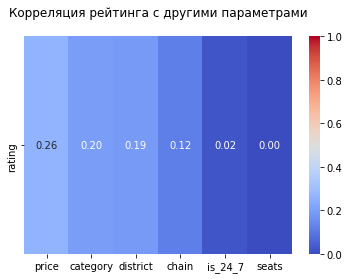

In [49]:
# используем все нужные признаки
cols = ['category', 'district', 'rating', 'chain', 'seats', 'price', 'is_24_7']
df_clean = df_processed[cols].copy()

# price как категориальный признак
df_clean['price'] = df_clean['price'].astype('category')

# корреляционная матрица (phik сам определит типы)
corr_matrix = df_clean.phik_matrix()
display(corr_matrix)

# корреляции с рейтингом
rating_corr = corr_matrix['rating'].drop('rating').sort_values(ascending=False)
display(rating_corr)

# тепловая карта только для столбца rating
plt.figure(figsize=(6, 4))
sns.heatmap(rating_corr.to_frame().T, annot=True, cmap='coolwarm', vmin=0, vmax=1, fmt='.2f')
plt.title('Корреляция рейтинга с другими параметрами', pad=20)
plt.show()

По графику видно, что явной зависимости почти нет.
Чуть сильнее всего рейтинг «тянет» цена: у более дорогих мест оценки немного выше -0.26.
Категория заведения и район дают слабые намёки на связь (0.20 и 0.19).
Сетевой статус — едва заметно - 0.12, круглосуточный режим — почти ноль 0.02, количество мест — совсем никак 0.00.

In [50]:
# Комментарий ревьюера
len(df), len(df_clean)

(8406, 8406)

Сравним средние рейтинги по группам:

In [51]:
df.groupby('price')['rating'].mean().sort_values(ascending=False)

price
высокие          4.436611
выше среднего    4.386348
средние          4.297874
низкие           4.173077
Name: rating, dtype: float32

Самые высокие средние рейтинги у заведений с ценами высокие (4.44) и выше среднего (4.39). 
А самые низкие — у заведений с ценами низкие (4.18).

Заведения премиум-сегмента получают высшие оценки. Это может говорить о более высоком уровне сервиса, атмосферы и удовлетворённости клиентов.

Категория заведения влияет на рейтинг:

In [52]:
df.groupby('category')['rating'].mean().sort_values(ascending=False)

category
бар,паб            4.387712
пиццерия           4.301264
ресторан           4.290357
кофейня            4.277282
булочная           4.268359
столовая           4.211429
кафе               4.123886
быстрое питание    4.050249
Name: rating, dtype: float32

- Лучше всего оцениваются бары/пабы (4.39), пиццерии (4.30), рестораны (4.29).
- Ниже рейтинги у столовых (4.21), кафе (4.12) и особенно у заведений “быстрое питание” (4.05).

Наиболее высокие рейтинги у заведений, где посетители ожидают высокого уровня сервиса и кухни.

Быстрое питание и столовые — получают самые низкие оценки, вероятно, из-за простоты формата и уровня обслуживания.

Административный район (district) влияет на рейтинг.

In [53]:
df.groupby('district')['rating'].agg(['mean', 'count']).sort_values('mean', ascending=False)

,mean,count
district,,
Центральный АО,4.377520,2242
Северный АО,4.239778,900
Северо-Западный АО,4.208802,409
Южный АО,4.184417,892
Западный АО,4.181551,851
Восточный АО,4.174185,798
Юго-Западный АО,4.172920,709
Северо-Восточный АО,4.148261,891
Юго-Восточный АО,4.101120,714


- Самый высокий рейтинг в Центральном АО (4.38) — и больше всего заведений (2242).
- Ниже всех рейтинг в Юго-Восточном АО (4.10).

В центре Москвы больше заведений с высоким рейтингом.
Это может быть связано с более высокой конкуренцией, уровнем сервиса, туристическим потоком и доходом клиентов.

Распределение рейтинга по ценовым категориям

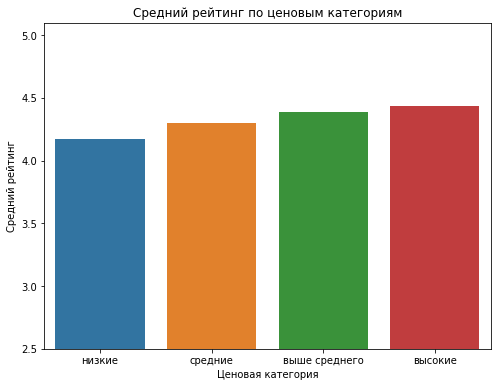

In [54]:
plt.figure(figsize=(8, 6))
sns.barplot(
    x='price',
    y='rating',
    data=df_clean,
    order=['низкие', 'средние', 'выше среднего', 'высокие'],
    estimator=mean,
    ci=None
)
plt.title('Средний рейтинг по ценовым категориям')
plt.xlabel('Ценовая категория')
plt.ylabel('Средний рейтинг')
plt.ylim(2.5, 5.1)
plt.xticks(rotation=0)
plt.show()

- Средний рейтинг заведения повышается с ростом ценовой категории.
- Самый высокий рейтинг наблюдается у заведений с высокими ценами.
- Самый низкий рейтинг — у заведений с низкими ценами.

Заведения с более высокой ценовой категорией получают более высокие оценки от пользователей. Это может указывать на то, что посетители:
- получают более качественный сервис,
- ожидают лучшую атмосферу и комфорт,
- более удовлетворены своим посещением.

Таким образом, уровень цен может служить косвенным индикатором качества заведения в глазах клиентов.

### 3.7 Самые популярные сетевые заведения

Теперь найдем топ-15 популярных сетей в Москве. Для них посчитаем значения среднего рейтинга. Под популярностью понимаем количество заведений этой сети в регионе. К какой категории заведений они относятся. Результат сопроводим подходящими визуализациями.

In [55]:
# Сводная таблица по сетевым заведениям 
df['name_normalized'] = (
    df['name'].astype(str).str.lower()
      .str.replace(r"[^\w\sё-]", " ", regex=True)   # убираем знаки препинания
      .str.replace(r"\s+", " ", regex=True)        # заменяем множественные пробелы на один
      .str.strip()
)

# список "генериков" — общих слов, которые не являются брендами
generic = {
    'кафе', 'ресторан', 'бар', 'кофейня', 'столовая',
    'пекарня', 'кондитерская', 'пиццерия', 'шаурма',
    'суши', 'бургерная', 'стейкхаус', 'булочная',
    'чебуречная', 'фастфуд', 'еда'
}

# удаляем генерики
df = df[~df['name_normalized'].isin(generic)]

# фильтруем только сетевые заведения
df_chain = df[df['chain'] == True]

# Сводная таблица по сетевым заведениям 

top_chains = (
    df.groupby(['name_normalized', 'category'])
      .agg(
          count_object=('id', 'count'),
          mean_rating=('rating', 'mean')
      )
      .reset_index()
      .query('count_object >= 5') 
      .sort_values(by='count_object', ascending=False)
)

display(top_chains.head(15))

,name_normalized,category,count_object,mean_rating
5831,шоколадница,кофейня,119,4.178151
2707,домино с пицца,пиццерия,77,4.171429
2672,додо пицца,пиццерия,74,4.286487
1201,one price coffee,кофейня,72,4.069445
5907,яндекс лавка,ресторан,72,3.855556
426,cofix,кофейня,65,4.075385
1340,prime,ресторан,49,4.114285
3396,кофепорт,кофейня,42,4.147619
3460,кулинарная лавка братьев караваевых,кафе,39,4.394872
5048,теремок,ресторан,36,4.105556


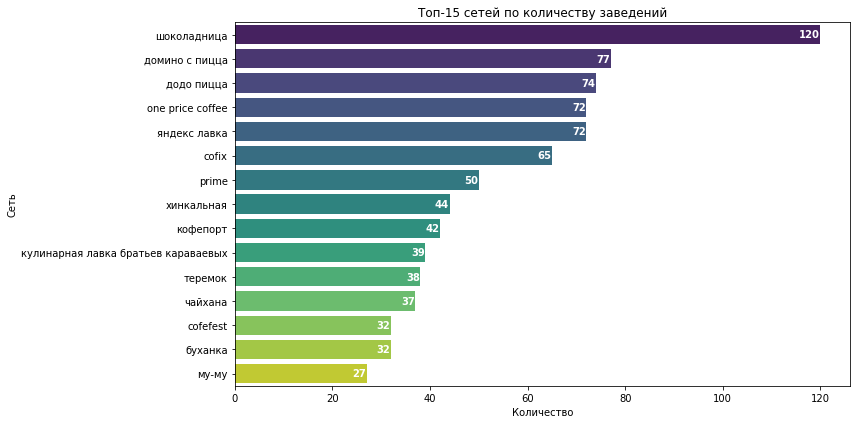

In [56]:
# Анализируем топ-15 сетевых брендов по количеству заведений

agg = {'id': 'count', 'rating': 'mean'}
if 'category' in df.columns:
    agg['category'] = 'first'

top_chains = (
    df.groupby('name_normalized', as_index=False)
      .agg(agg)
      .rename(columns={'id': 'count', 'rating': 'mean_rating'})
      .query('count >= 5')
      .sort_values('count', ascending=False)
      .head(15)
)

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=top_chains, x='count', y='name_normalized', palette='viridis')

for p in ax.patches:
    value = p.get_width()
    if not pd.isna(value):
        ax.annotate(f"{int(value)}",
                    (p.get_x() + value - 0.1, p.get_y() + p.get_height()/2),
                    ha='right', va='center', fontsize=10,
                    color='white', fontweight='bold')

ax.set_title('Топ-15 сетей по количеству заведений')
ax.set_xlabel('Количество')
ax.set_ylabel('Сеть')
plt.tight_layout()
plt.show()

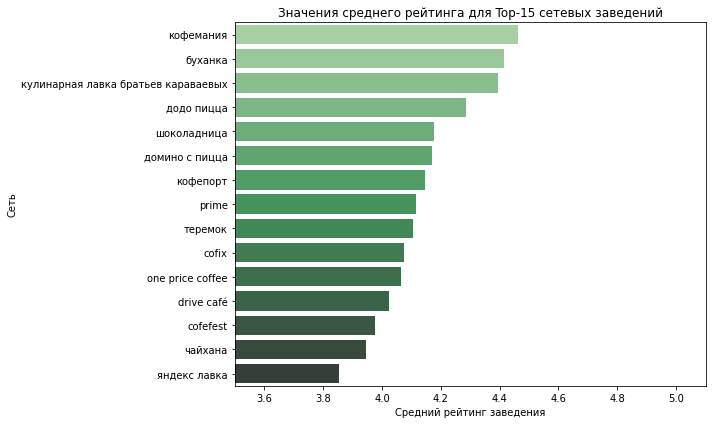

In [57]:
# Строим горизонтальную столбчатую диаграмму среднего рейтинга
top15_pairs = (
    df[df['chain'] == True]
      .groupby(['name_normalized', 'category'], as_index=False)
      .agg(count_object=('id', 'count'),
           mean_rating=('rating', 'mean'))
      .query('count_object >= 5')
      .sort_values('count_object', ascending=False)
      .head(15)
)


plt.figure(figsize=(10, 6))
sns.barplot(
    data=top15_pairs.sort_values('mean_rating', ascending=False),
    y='name_normalized',
    x='mean_rating',
    palette='Greens_d'
)

plt.title('Значения среднего рейтинга для Top-15 сетевых заведений')
plt.xlabel('Средний рейтинг заведения')
plt.ylabel('Сеть')
plt.xlim(3.5, 5.1)
plt.tight_layout()
plt.show()

In [58]:
# проверка
tmp = df.copy()          # создаем копию текущего датасета
name_tmp = 'му-му'       # задаем имя столбца для проверки уникальных категорий
print(f'Заведения с одинаковым именем {name_tmp} относятся к разным категориям:\n\
{", ".join(tmp[tmp.name_normalized == name_tmp].category.unique())}')

Заведения с одинаковым именем му-му относятся к разным категориям:
кафе, ресторан, кофейня, быстрое питание, пиццерия, столовая, бар,паб


**Самые популярные сети**:
- Шоколадница — лидер по количеству заведений (120), категория: кофейня.
- Далее идут пиццерии Domino’s (77) и Додо пицца (74).
- Также в топе: кофейни (one price coffee, cofix), рестораны (яндекс лавка, prime).

**Высокий средний рейтинг**:
- Кофемания — несмотря на меньшее количество точек (22), имеет один из самых высоких средних рейтингов (4.46).
- Буханка (булочная) также отличается высоким рейтингом — 4.42.
- В целом, кофейни и булочные чаще имеют рейтинг выше 4.1.

**Ниже среднего**:
- У чайханы и coffefest рейтинг ближе к 3.9 — это ниже, чем у других заведений из топа.

Среди сетевых заведений наибольшее распространение имеют кофейни и пиццерии — они занимают лидирующие позиции по количеству объектов. Это может быть связано с их массовым спросом, невысокой себестоимостью и быстрой окупаемостью.

В то же время, заведения с меньшим числом точек, такие как Кофемания и Буханка, получают высокие пользовательские оценки. Это может говорить об ориентации на более качественный сервис и премиальный сегмент.

Таким образом, масштаб сети не всегда означает высокий рейтинг — пользователи выше оценивают качество, атмосферу и уровень обслуживания, даже если у сети меньше точек.

### 3.8 Средний чек заведений
Значения средних чеков заведений хранятся в столбце `middle_avg_bill`. Проанализируем цены в Центральном административном округе и других.

Посчитаем статистику по middle_avg_bill

In [59]:
# Статистика по среднему чеку
df['middle_avg_bill'].describe()

count     3128.000000
mean       951.314270
std        808.085754
min          0.000000
25%        385.000000
50%        750.000000
75%       1250.000000
max      11000.000000
Name: middle_avg_bill, dtype: float64

- 3149 заведений имеют средний чек.
- Средний чек (mean): 958 рублей,  т.е в среднем по всем заведениям города посетители тратят около 950–960 ₽.
Это значит, что половина всех заведений имеют средний чек в диапазоне от 385 до 1250 ₽.
- Стандартное отклонение: 808 рублей — указывает на довольно сильную вариативность цен.

Посчитаем медиану и среднее по административным округам

In [60]:
district_stats = (
    df.groupby('district')['middle_avg_bill']
    .agg(['median', 'mean'])
    .reset_index()
    .sort_values(by='median', ascending=False)
)

display(district_stats)

,district,median,mean
1,Западный АО,1000.0,1057.358521
5,Центральный АО,1000.0,1191.804565
4,Северо-Западный АО,700.0,830.283875
2,Северный АО,650.0,932.196899
7,Юго-Западный АО,650.0,796.575134
0,Восточный АО,600.0,831.448792
3,Северо-Восточный АО,500.0,718.166687
8,Южный АО,500.0,729.938721
6,Юго-Восточный АО,450.0,656.139893


**Наиболее дорогие округа (по медиане)**: Западный АО и Центральный АО — лидеры, медиана чека составляет 1000 руб.
При этом в ЦАО наблюдается самое высокое среднее значение чека — 1192 руб., что говорит о наличии заведений премиум-сегмента или аномально высоких значений.
В Западном АО среднее ниже — 1057 руб., значит, распределение там более равномерное, с меньшим количеством выбросов.

**Средний ценовой уровень**: Северный, Северо-Западный, Юго-Западный АО — медиана от 650 руб. до 700 руб.
 Это может быть связано с умеренными арендными ставками и ориентиром на массового потребителя.

**Наиболее дешёвые округа**: Юго-Восточный АО — самая низкая медиана 450 руб., и самое низкое среднее значение 656 руб..
Это может говорить об эконом-сегменте заведений, либо менее обеспеченной аудитории.


Центральный округ выделяется высокой средней ценой, что ожидаемо: это центр столицы, с туристическим потоком, элитными заведениями и высокой арендой.
В ряде округов среднее значение значительно превышает медиану (например, в ЦАО и СЗАО), что указывает на выбросы в сторону дорогих чеков.
Округа с невысокой медианой и средним (например, ЮВАО, ЮАО, СВАО) скорее ориентированы на повседневный, недорогой сегмент

Построим горизонтальный barplot по медиане и среднему

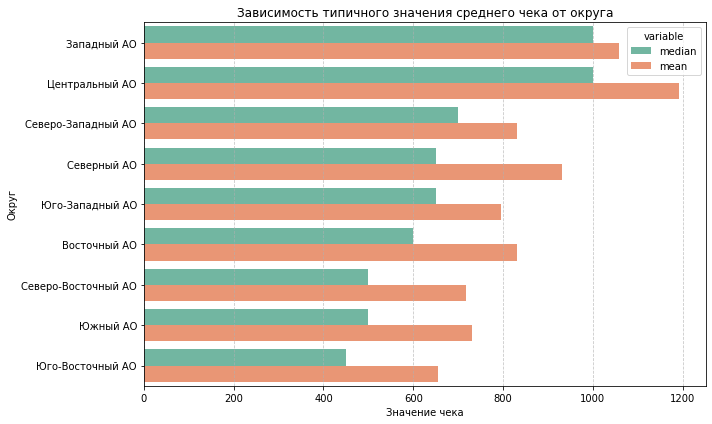

In [61]:
plt.figure(figsize=(10, 6))
district_stats_melted = district_stats.melt(id_vars='district', value_vars=['median', 'mean'])

sns.barplot(
    data=district_stats_melted,
    x='value',
    y='district',
    hue='variable',
    palette='Set2'
)

plt.title('Зависимость типичного значения среднего чека от округа')
plt.xlabel('Значение чека')
plt.ylabel('Округ')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Самые дорогие округа по чеку**: Западный АО и Центральный АО лидируют по медианному значению среднего чека — 1000 руб.
При этом в ЦАО среднее значение выше медианы (1192 руб. против 1000 руб.), что говорит о наличии заведений с очень высоким чеком — вероятно, это премиальные рестораны в центре города.

В Западном АО разрыв между медианой и средним меньше, распределение более равномерное.

**Средний сегмент** (медиана 650–700 руб.):
- Северный АО (650 руб.),
- Северо-Западный АО (700 руб.),
- Юго-Западный АО (650 руб.).
Эти округа, вероятно, ориентированы на более широкую аудиторию с умеренной платёжеспособностью.

**Наименее дорогие округа**:
- Юго-Восточный АО имеет самую низкую медиану — 450 руб. и среднее значение — 656 руб.
Это говорит о концентрации эконом-сегмента заведений: столовые, кафе при производстве, фастфуд.

**Округа с большим разбросом цен**:
- В Центральном, Южном, Восточном АО средние значения заметно выше медианных - есть выбросы (заведения с очень высокими чеками).
- В Северном, СВАО и ЮВАО разница между медианой и средним незначительна - распределение симметричное, заведения более равномерны по ценам.

- В центре Москвы чек выше, что логично: высокая арендная ставка, престижное расположение, ориентация на премиум-рынок и туристов.
- В отдалённых округах (например, ЮВАО, СВАО) цены ниже — заведения там рассчитаны на местных жителей, а не на туристов или премиум-сегмент.
- Разница между медианой и средним важна: чем больше разрыв — тем больше влияние выбросов (очень дорогих заведений). Там, где они близки — ценовая политика более стабильна.

Сравнение ЦАО и остальных округов

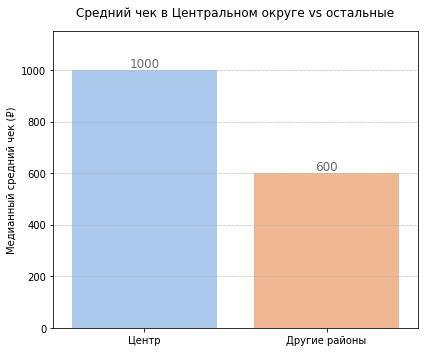

In [62]:
central_avg = df[df['district'] == 'Центральный АО']['middle_avg_bill'].median()
non_central_avg = df[df['district'] != 'Центральный АО']['middle_avg_bill'].median()

plt.figure(figsize=(6, 5))
ax = sns.barplot(
    x=['Центр', 'Другие районы'],
    y=[central_avg, non_central_avg],
    palette='pastel'
)

# Подписи на столбцах
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.0f}',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center', va='bottom',
        fontsize=12, color='dimgrey'
    )

plt.title('Средний чек в Центральном округе vs остальные', pad=15)
plt.ylabel('Медианный средний чек (₽)')
plt.ylim(0, max(central_avg, non_central_avg) * 1.15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Средний чек в Центре составляет 1000 ₽, тогда как в других районах — 600 ₽.
Таким образом, в центре города средний чек выше на 40%, что может быть связано с:
- более высоким уровнем цен на аренду и обслуживание;
- ориентацией заведений на премиум-сегмент и туристов;
- общим уровнем благосостояния аудитории центра.

Построим гистограмму и boxplot

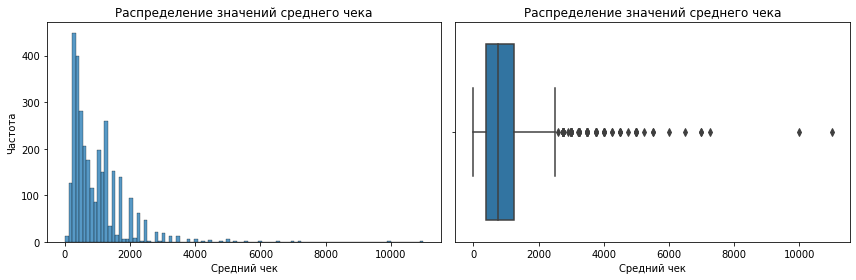

In [63]:
plt.figure(figsize=(12, 4))

# Гистограмма
plt.subplot(1, 2, 1)
sns.histplot(df['middle_avg_bill'], bins=100, kde=False)
plt.title('Распределение значений среднего чека')
plt.xlabel('Средний чек')
plt.ylabel('Частота')

# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x=df['middle_avg_bill'])
plt.title('Распределение значений среднего чека')
plt.xlabel('Средний чек')

plt.tight_layout()
plt.show()

- Распределение резко скошено вправо (положительная асимметрия).
- Основная масса заведений (больше 800 объектов) имеет средний чек до 1500 рублей.
- После 3000 рублей начинается длинный «хвост» с редкими значениями — это дорогие заведения или выбросы.
Видно большое количество выбросов справа — значений, значительно превышающих 1.5×IQR. Медиана примерно на уровне 750 руб., в большинстве заведений чек ниже 1000 руб. Есть экстремальные значения до 10 000 рублей, которые сильно влияют на среднее.

- Распределение не является нормальным, оно асимметрично и содержит выбросы.
- Медианное значение (750 руб.) ниже среднего (около 960 руб.), так как устойчиво к аномально высоким значениям.
- Приписывать высокие значения может указывать на элитные рестораны, ошибки в данных (например, нулевой чек) или редкие заведения с очень дорогим меню

### Общие выводы третьего шага
Итак, на этапе третьего шага была проделана большая работа по анализу данных, вот что мы сделали:

3.1. Проанализировали категории заведений

3.2. Вывели административные районы Москвы

3.3. Изучили соотношение сетевых заведения

3.4. Иследовали количество посадочных мест

3.5. Распределили средний рейтинг по категориям заведений

3.6. Для оценки факторов, влияющих на рейтинг заведений, построили  корреляция.

3.7. Вывели самые популярные сетевые заведения

3.8. Изучили вариацию средний чек заведений

1. **Проанализировали категории заведений**.

Заведения распределены по категорям неравномерно, мы видим, что в топе графика находится категория "кафе", у которой **2378** заведений, далее идут "рестораны" и "кофейни" (**2043** и **1413** заведений).

2. **Произвели сравнение категорий заведений в ЦАО и по всей Москве**: 

- в ЦАО на первом месте находяться рестораны (670, 29.9%), на втором кафе (464, 20.7%) и на третьем кофейни (428, 19.1%)

- в категории во всех округах москвы, то на первом месте находиться кафе (2378, 28,3%), на втором рестораны (2043, 24,3%) и на третьем кофейни (1413, 16,8%)

В ЦАО на первом месте находятся рестораны, в то время как в среднем по Москве лидируют кафе.
Это может объясняться высокой концентрацией туристов и бизнес-центров в ЦАО, где чаще встречаются форматы "ресторанного типа".


3. **Посчитали соотношение сетевых и несетевых заведений**:

- сетевые заведения **38.1%**
- несетевын заведения **61.9%**.

Я сравнила, в абсолюном количестве сетевые и несетевые заведения, несетевых больше на 1996 заведений. 

4. **Самые вместительные категории**: рестораны и бары/пабы (медиана около 82–86 мест).

**Наибольшая вариативность**: заведения быстрого питания и кофейни отражает разные форматы: от небольших точек до больших залов.

**Самые компактные**: булочные и пиццерии (медиана около 50–55 мест).
В целом, большинство категорий показывают значительный разброс, что указывает на разнообразие форматов внутри каждой группы.


5. Распределение по среднему рейтингу среди всех категорий практически однородно. Наивысший рейтинг у категории "баров и пабов" - 4.30, а на последнем месте находятся заведения категории "быстрого питания" - 4.05.

6. Лучше всего оцениваются бары/пабы (4.39), пиццерии (4.30), рестораны (4.29).
Ниже рейтинги у столовых (4.21), кафе (4.12) и особенно у заведений “быстрое питание” (4.05).
Наиболее высокие рейтинги у заведений, где посетители ожидают высокого уровня сервиса и кухни.

Быстрое питание и столовые — получают самые низкие оценки, вероятно, из-за простоты формата и уровня обслуживания.

7. **Самые популярные сети**:
- Шоколадница — лидер по количеству заведений (120), категория: кофейня.
- Далее идут пиццерии Domino’s (77) и Додо пицца (74).
- Также в топе: кофейни (one price coffee, cofix), рестораны (яндекс лавка, prime).

**Высокий средний рейтинг**:
- Кофемания — несмотря на меньшее количество точек (22), имеет один из самых высоких средних рейтингов (4.46).
- Буханка (булочная) также отличается высоким рейтингом — 4.42.
- В целом, кофейни и булочные чаще имеют рейтинг выше 4.1.

**Ниже среднего**:
- У чайханы и coffefest рейтинг ближе к 3.9 — это ниже, чем у других заведений из топа.

Среди сетевых заведений наибольшее распространение имеют кофейни и пиццерии — они занимают лидирующие позиции по количеству объектов. Это может быть связано с их массовым спросом, невысокой себестоимостью и быстрой окупаемостью.

В то же время, заведения с меньшим числом точек, такие как Кофемания и Буханка, получают высокие пользовательские оценки. Это может говорить об ориентации на более качественный сервис и премиальный сегмент.

Таким образом, масштаб сети не всегда означает высокий рейтинг — пользователи выше оценивают качество, атмосферу и уровень обслуживания, даже если у сети меньше точек.


8. Центральный округ выделяется высокой средней ценой, что ожидаемо: это центр столицы, с туристическим потоком, элитными заведениями и высокой арендой.
В ряде округов среднее значение значительно превышает медиану (например, в ЦАО и СЗАО), что указывает на выбросы в сторону дорогих чеков.
Округа с невысокой медианой и средним (например, ЮВАО, ЮАО, СВАО) скорее ориентированы на повседневный, недорогой сегмент.

### Шаг 4. Итоговые выводы и рекомендации

**Цель исследования**

Инвесторы фонда Shut Up and Take My Money планируют открыть новое заведение общественного питания в Москве. Формат — кафе, ресторан или бар — пока не определён. 

Задача проекта заключалась в том, чтобы провести исследовательский анализ рынка: изучить категории заведений, особенности их распределения по округам, оценить уровень цен, рейтинги и популярность сетевых брендов. Полученные результаты помогут инвесторам выбрать оптимальный формат и место для будущего бизнеса.

**Произвели первичный анализ и предобработка данных**

Для работы были предоставлены два датасета: с информацией о заведениях и о среднем чеке.

На этапе первичного анализа мы проверили объём и структуру данных, выявили пропуски и некорректные значения, а также привели столбцы к нужным типам. Данные были объединены в единый массив, что позволило использовать их в дальнейшем анализе.
Важно отметить, что данные были собраны из открытых источников и сервисов Яндекса. Данные могли быть неполными или содержать неточности, поэтому это важно учитывать при оценке результатов анализа

**Основные результаты анализа**

- **Категории заведений**

В Москве лидируют рестораны - 29,9%, кафе - 20.7% и кофейни - 19,1% . При этом в Центральном округе на первом месте рестораны, что объясняется деловой активностью и туристическим потоком.

- **Сетевые и несетевые заведения**

Сетевые объекты составляют 38.1%, несетевые — 61,9%. В абсолютных значениях несетевых заведений на 1996 больше.
*38.1%**

- **Посадочные места**

Самые вместительные — рестораны и бары (≈80 мест), самые компактные — булочные и пиццерии (≈50 мест). Разброс внутри категорий большой: встречаются и маленькие точки, и заведения на сотни гостей.

- **Средний рейтинг**

В целом заведения оцениваются стабильно — от 4.0 до 4.4.
Выше всего рейтинг у баров/пабов (4.39), пиццерий (4.30) и ресторанов (4.29).
Ниже всего — у фастфуда (4.05). Это связано с ожиданиями гостей: чем выше формат и сервис, тем выше оценки.

- **Популярные сети**

По количеству точек лидирует Шоколадница (120), далее Domino’s (77) и Додо Пицца (74).
Однако по качеству выделяются сети: Кофемания и Буханка, которые при меньшем числе филиалов получают самые 
высокие оценки пользователей.

- **Средний чек**

В среднем по городу посетители тратят около 950 ₽, а половина заведений укладывается в диапазон 385–1250 ₽.
В ЦАО и ЗАО средний чек выше (около 1000 ₽), в ЮВАО — самый низкий (около 450 ₽). Таким образом, цены заметно различаются в зависимости от района.


**Общие выводы**

Рынок Москвы разнообразен, но основу составляют кафе, рестораны и кофейни.

Центр города дороже и престижнее: здесь выше средний чек и больше ресторанов, тогда как в спальных районах популярны доступные кафе и фастфуд.

Сетевые бренды занимают важную долю, но несетевых заведений всё же больше.

Популярность не всегда равна качеству: небольшие премиальные сети получают более высокие оценки, чем крупные.

Средний чек позволяет выделить три сегмента:
доступные заведения (ЮВАО, ЮАО, СВАО),
средний сегмент (большинство районов),
премиальный сегмент (ЦАО, ЗАО).